In [1]:
#By Cristian Cruz 
pip install scapy
!pip install pyx cryptography

SyntaxError: invalid syntax. Perhaps you forgot a comma? (732551504.py, line 2)

In [2]:
from scapy.all import *

In [2]:
#Creamos un paquete loopback IP
paquete = IP(ttl=10)
print(type(paquete))
print(paquete)


<class 'scapy.layers.inet.IP'>
127.0.0.1 > 127.0.0.1 ip


In [3]:
print("Dirección IP de origen:", paquete.src)
print("Dirección IP de destino:",paquete.dst)
print("TTL:",paquete.ttl)
#si se elimina el campo ttl, se reestablece a 64c
del(paquete.ttl)
print("TTL:",paquete.ttl)

Dirección IP de origen: 127.0.0.1
Dirección IP de destino: 127.0.0.1
TTL: 10
TTL: 64


In [4]:
# Creación de un paquete IP con TTL = 10
paquete = IP(ttl=10)

# Asignación de la dirección IP de origen y destino
paquete.src = "10.23.213.20"
paquete.dst = "8.8.8.8"

print("Dirección IP de origen:", paquete.src)
print("Dirección IP de destino:", paquete.dst)

#Parámetros del paquete
paquete.show()

Dirección IP de origen: 10.23.213.20
Dirección IP de destino: 8.8.8.8
###[ IP ]###
  version   = 4
  ihl       = None
  tos       = 0x0
  len       = None
  id        = 1
  flags     = 
  frag      = 0
  ttl       = 10
  proto     = ip
  chksum    = None
  src       = 10.23.213.20
  dst       = 8.8.8.8
  \options   \



## Apilamiento de Capas

El apilamiento de capas significa que puedes combinar diferentes protocolos en un solo paquete. Cada capa representa un protocolo diferente en el modelo OSI o TCP/IP, como IP, TCP, UDP, ICMP, etc. Las capas superiores de la pila utilizan las capas inferiores para el transporte y la entrega de datos.

# Ejemplo básico de apilamiento de capas:

Imagina que quieres crear un paquete que tenga las siguientes capas:

Capa 3 (Red): Un paquete IP
Capa 4 (Transporte): Un paquete TCP
Capa 5 (Aplicación): Datos del protocolo HTTP

Scapy te permite apilar estos protocolos fácilmente, con cada capa agregando más detalles y funcionalidad al paquete. Para ello se emplea el operador (/)
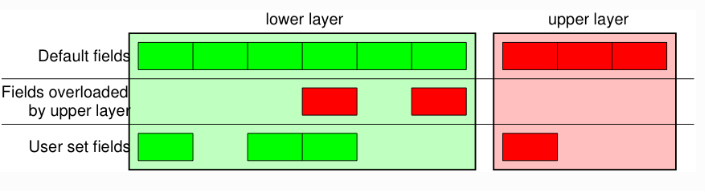

In [5]:
IP()

<IP  |>

In [6]:
IP()/TCP()

<IP  frag=0 proto=tcp |<TCP  |>>

In [7]:
Ether()/IP()/TCP()

<Ether  type=IPv4 |<IP  frag=0 proto=tcp |<TCP  |>>>

In [8]:
IP()/TCP()/"GET / HTTP/1.0\r\n\r\n"

<IP  frag=0 proto=tcp |<TCP  |<Raw  load=b'GET / HTTP/1.0\r\n\r\n' |>>>

In [9]:
Ether()/IP()/IP()/UDP()

<Ether  type=IPv4 |<IP  frag=0 proto=4 |<IP  frag=0 proto=udp |<UDP  |>>>>

In [10]:
IP(proto=55)/TCP()

<IP  frag=0 proto=55 |<TCP  |>>

In [11]:
##Representación cruda, de un paquete IP
raw(IP())

#raw() en  convierte un paquete o cualquier capa en una secuencia de bytes crudos

b'E\x00\x00\x14\x00\x01\x00\x00@\x00|\xe7\x7f\x00\x00\x01\x7f\x00\x00\x01'

In [12]:
IP(_)

<IP  version=4 ihl=5 tos=0x0 len=20 id=1 flags= frag=0 ttl=64 proto=ip chksum=0x7ce7 src=127.0.0.1 dst=127.0.0.1 |>

In [13]:
a=Ether()/IP(dst="www.slashdot.org")/TCP()/"GET /index.html HTTP/1.0 \n\n"
print(a)

Ether / IP / TCP 10.23.213.20:ftp_data > Net("www.slashdot.org/32"):http S / Raw


In [14]:
hexdump(a)

0000  F6 A4 E1 1C 3C 2F 20 4E F6 09 9C 0B 08 00 45 00  ....</ N......E.
0010  00 43 00 01 00 00 40 06 2D A0 0A 17 D5 14 68 12  .C....@.-.....h.
0020  05 D7 00 14 00 50 00 00 00 00 00 00 00 00 50 02  .....P........P.
0030  20 00 70 9D 00 00 47 45 54 20 2F 69 6E 64 65 78   .p...GET /index
0040  2E 68 74 6D 6C 20 48 54 54 50 2F 31 2E 30 20 0A  .html HTTP/1.0 .
0050  0A                                               .


In [15]:
b=raw(a)
print(b)

b'\xf6\xa4\xe1\x1c</ N\xf6\t\x9c\x0b\x08\x00E\x00\x00C\x00\x01\x00\x00@\x06-\xa0\n\x17\xd5\x14h\x12\x05\xd7\x00\x14\x00P\x00\x00\x00\x00\x00\x00\x00\x00P\x02 \x00p\x9d\x00\x00GET /index.html HTTP/1.0 \n\n'


In [16]:
Ether(b)


<Ether  dst=f6:a4:e1:1c:3c:2f src=20:4e:f6:09:9c:0b type=IPv4 |<IP  version=4 ihl=5 tos=0x0 len=67 id=1 flags= frag=0 ttl=64 proto=tcp chksum=0x2da0 src=10.23.213.20 dst=104.18.5.215 |<TCP  sport=ftp_data dport=http seq=0 ack=0 dataofs=5 reserved=0 flags=S window=8192 chksum=0x709d urgptr=0 |<Raw  load=b'GET /index.html HTTP/1.0 \n\n' |>>>>

## Construir un paquete de solicitud hacia google

In [49]:
#Paso 1: Identificar las capas y los protocolos involucrados
#Segun el modelo TCP/IP
#1: capa de aplicación (HTTP)
#2: capa de transporte (TCP)
#3: Capa de red (IP)
#4: capa de enlace de datos (Ethernet)
import socket

# Resolver IP de dominio
ip = socket.gethostbyname("google.com")

#1: En la capa de aplicación
http_request = b"GET / HTTP/1.1\r\nHost: www.google.com\r\n\r\n"

#2: Capa de transporte
# - puerto 80 es el puerto HTTP estándar.
# - flags: 'S' para SYN (sincronización de conexión).
#tcp = TCP(dport=80, sport=RandShort(), flags="S", seq=1000)
tcp = TCP(dport=80, sport=22725, flags="S", seq=1000)
#3: Capa de red (IP)
ip = IP(dst=ip)  # Dirección IP de Google (puedes usar la función 'gethostbyname' para buscarla automáticamente)

#4: Construimos el paquete
paquete = ip/tcp

# Enviar el paquete SYN y esperar la respuesta (SYN-ACK)
respuesta = sr1(paquete, timeout=10)
respuesta.show()



Received 2 packets, got 1 answers, remaining 0 packets
###[ IP ]###
  version   = 4
  ihl       = 5
  tos       = 0x30
  len       = 40
  id        = 15925
  flags     = 
  frag      = 0
  ttl       = 119
  proto     = tcp
  chksum    = 0xb8f4
  src       = 172.217.192.113
  dst       = 10.23.213.20
  \options   \
###[ TCP ]###
     sport     = http
     dport     = 22725
     seq       = 2431414331
     ack       = 1001
     dataofs   = 5
     reserved  = 0
     flags     = A
     window    = 65535
     chksum    = 0x538
     urgptr    = 0
     options   = []



En esta parte, se puede observar, como se ha enviado un paquete hacia la ip de google (Se intenta establecer la conexión con un flag=S). El Servidor de google, responde con un SA, indicando que acepta la conexión. Sin embargo, hasta este punto al no enviar ningun packete con el ACK, el servidor infiere que se ha perdido nuestro paquete por lo que hace las retransmisiones. 

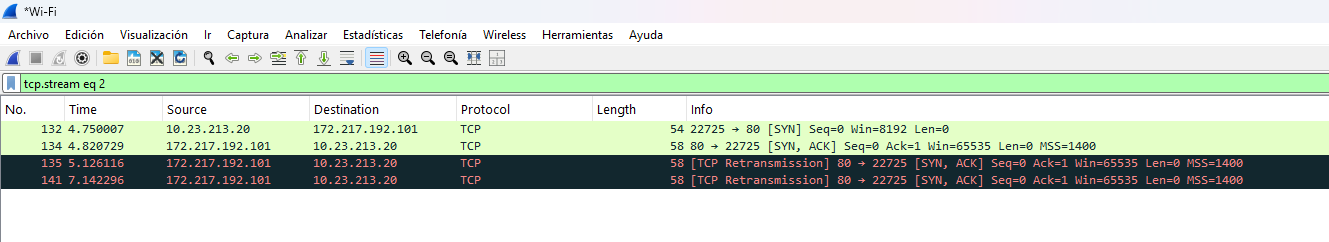


In [50]:
# Responder con un paquete ACK para completar el handshake
tcp_ack = TCP(dport=respuesta.sport, sport=respuesta.dport, flags="A", seq=respuesta.ack, ack=respuesta.seq + 1)
ack_paquete = ip/tcp_ack
respuesta_ack = sr1(ack_paquete, timeout=10)
respuesta_ack.show()


Received 32 packets, got 0 answers, remaining 1 packets


AttributeError: 'NoneType' object has no attribute 'show'

In [15]:
from scapy.all import *
import base64
import time

packets = [
    "aA5SUVNDU1PpRY7JCjcgBRMCPCPQAnci",
    "bCxTglRjU1OGgIAw8uEH2LIBlK8DKwDEAQAAAAAAAADcwebpC+y3gO4L57b6+wMAACQAAACyrAU=",
    "ZztTglRjU1OGgIAw8uEH2LIBlK8DKwDEAQAAAAAAAADcwebpC++3gO4L57b6+wMAACQAAACVrQU=",
    "aURTglRjU1OGgIAw8uEH2LIBlK8DKwDEAQAAAAAAAADcwebpC/K3gO4L57b6+wMAACQAAAD4rQU=",
    "agZTUFNbU1PMmrACjgEAAA=="
    
]

for p in packets:
    data = base64.b64decode(p)
    send(IP(dst="23.251.41.119")/UDP(dport=10015)/data)
    time.sleep(0.02)


Sent 1 packets.

Sent 1 packets.

Sent 1 packets.

Sent 1 packets.

Sent 1 packets.


In [ ]:
  - packet: 954
    peer: 1
    index: 465
    timestamp: 1775999720.221338000
    data: !!binary |
      aA5SUVNDU1PpRY7JCjcgBRMCPCPQAnci
  - packet: 955
    peer: 1
    index: 466
    timestamp: 1775999720.294942000
    data: !!binary |
      bCxTglRjU1OGgIAw8uEH2LIBlK8DKwDEAQAAAAAAAADcwebpC+y3gO4L57b6+wMAACQAAACyrAU=
  - packet: 956
    peer: 1
    index: 467
    timestamp: 1775999720.395268000
    data: !!binary |
      ZztTglRjU1OGgIAw8uEH2LIBlK8DKwDEAQAAAAAAAADcwebpC++3gO4L57b6+wMAACQAAACVrQU=
  - packet: 957
    peer: 1
    index: 468
    timestamp: 1775999720.494646000
    data: !!binary |
      aURTglRjU1OGgIAw8uEH2LIBlK8DKwDEAQAAAAAAAADcwebpC/K3gO4L57b6+wMAACQAAAD4rQU=
  - packet: 958
    peer: 1
    index: 469
    timestamp: 1775999720.559400000
    data: !!binary |
      agZTUFNbU1PMmrACjgEAAA==